# Machine Learning Classifier
## Attack Detection from PCAP Features

This notebook trains and evaluates three classifiers to detect attack 
traffic from packet-level features alone, without deep packet inspection.

**Dataset:** 240,722 packets across 7 traffic types  
**Target:** `is_attack` — binary (0 = normal, 1 = attack)

In [2]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded")

All libraries loaded


In [5]:
df = pd.read_csv('traffic_features.csv')

print("=" * 50)
print(f"Dataset shape: {df.shape}")
print("=" * 50)

print("\nPackets per traffic type:")
for tt, count in df['traffic_type'].value_counts().items():
    label = "ATTACK" if df[df['traffic_type']==tt]['is_attack'].iloc[0]==1 else "NORMAL"
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {tt:<22} {count:>7,}  {pct:5.1f}%  {bar}  [{label}]")

print(f"\nClass balance:")
normal = (df['is_attack']==0).sum()
attack = (df['is_attack']==1).sum()
print(f"  Normal (0): {normal:,}  ({normal/len(df)*100:.1f}%)")
print(f"  Attack (1): {attack:,}  ({attack/len(df)*100:.1f}%)")
print(f"\nNote: slight imbalance (59% attack vs 41% normal)")
print(f"This is acceptable — we will monitor per-class F1 scores")

Dataset shape: (240722, 11)

Packets per traffic type:
  queue_flood             93,088   38.7%  ███████████████████  [ATTACK]
  rest_normal             62,546   26.0%  ████████████  [NORMAL]
  rabbitmq_normal         26,300   10.9%  █████  [NORMAL]
  http_flood              22,351    9.3%  ████  [ATTACK]
  grpc_abuse              14,527    6.0%  ███  [ATTACK]
  slow_loris              13,143    5.5%  ██  [ATTACK]
  grpc_normal              8,767    3.6%  █  [NORMAL]

Class balance:
  Normal (0): 97,613  (40.6%)
  Attack (1): 143,109  (59.4%)

Note: slight imbalance (59% attack vs 41% normal)
This is acceptable — we will monitor per-class F1 scores


## 2. Feature Preparation

Features used for classification:

| Feature | Why included |
|---|---|
| `packet_length` | REST/gRPC/AMQP produce different sizes; floods produce uniform small packets |
| `inter_arrival_time` | Flood attacks have near-zero IAT; Slow Loris has high IAT |
| `dst_port` | Encodes protocol (8080=REST, 9090=gRPC, 5672=AMQP) |
| `tcp_flag_syn` | High SYN rate = connection flood characteristic |
| `tcp_flag_fin` | Low FIN with high SYN = incomplete connections (Slow Loris) |
| `tcp_flag_psh` | PSH indicates data-carrying packets |
| `tcp_flag_ack` | ACK-only packets vs data packets ratio |

**Excluded:** `timestamp`, `src_port`, `traffic_type` (timestamp leaks timing 
info, src_port is random, traffic_type is the label itself)

In [6]:
FEATURE_COLS = [
    'packet_length',
    'inter_arrival_time',
    'dst_port',
    'tcp_flag_syn',
    'tcp_flag_fin',
    'tcp_flag_psh',
    'tcp_flag_ack',
]

X = df[FEATURE_COLS].copy()
y = df['is_attack'].copy()

# Clip extreme IAT outliers (anything above 99th percentile)
# These are capture gaps, not real traffic behaviour
iat_cap = X['inter_arrival_time'].quantile(0.99)
X['inter_arrival_time'] = X['inter_arrival_time'].clip(upper=iat_cap)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeature value ranges:")
print(X.describe().round(4))

Feature matrix shape: (240722, 7)
Target vector shape:  (240722,)

Feature value ranges:
       packet_length  inter_arrival_time     dst_port  tcp_flag_syn  \
count    240722.0000         240722.0000  240722.0000   240722.0000   
mean        100.5496              0.0024   28663.2906        0.0216   
std         296.8614              0.0133   20692.3074        0.1453   
min          44.0000              0.0000       0.0000        0.0000   
25%          44.0000              0.0000    8080.0000        0.0000   
50%          64.0000              0.0000   21142.0000        0.0000   
75%          86.0000              0.0001   53184.0000        0.0000   
max       60617.0000              0.1004   63203.0000        1.0000   

       tcp_flag_fin  tcp_flag_psh  tcp_flag_ack  
count   240722.0000   240722.0000   240722.0000  
mean         0.0157        0.4672        0.9862  
std          0.1245        0.4989        0.1166  
min          0.0000        0.0000        0.0000  
25%          0.0000  

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class balance in both sets
)

print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")
print(f"\nClass balance in training set:")
print(f"  Normal: {(y_train==0).sum():,}  Attack: {(y_train==1).sum():,}")
print(f"Class balance in test set:")
print(f"  Normal: {(y_test==0).sum():,}  Attack: {(y_test==1).sum():,}")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nFeatures scaled for Logistic Regression (StandardScaler)")

Training set:  192,577 samples
Test set:      48,145 samples

Class balance in training set:
  Normal: 78,090  Attack: 114,487
Class balance in test set:
  Normal: 19,523  Attack: 28,622

Features scaled for Logistic Regression (StandardScaler)


In [8]:
print("Training classifiers...")
print()

# 1. Random Forest
print("1/3  Random Forest (n_estimators=100)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("     Done")

# 2. Decision Tree
print("2/3  Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
print("     Done")

# 3. Logistic Regression
print("3/3  Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("     Done")

print("\nAll classifiers trained successfully")

Training classifiers...

1/3  Random Forest (n_estimators=100)...
     Done
2/3  Decision Tree...
     Done
3/3  Logistic Regression...
     Done

All classifiers trained successfully


## 3. Model Evaluation

Each model is evaluated using:
- **Precision** — of all packets predicted as attack, how many actually were?
- **Recall** — of all actual attack packets, how many did we catch?
- **F1-Score** — harmonic mean of precision and recall (primary metric)
- **Accuracy** — overall correct predictions (secondary — can be misleading with imbalanced data)

In [9]:
models = {
    'Random Forest':    (rf,  X_test,        'RF'),
    'Decision Tree':    (dt,  X_test,        'DT'),
    'Logistic Regression': (lr, X_test_scaled, 'LR'),
}

results = {}

for name, (model, X_eval, short) in models.items():
    preds = model.predict(X_eval)
    report = classification_report(y_test, preds, 
                                   target_names=['Normal','Attack'],
                                   output_dict=True)
    results[name] = report
    
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(classification_report(y_test, preds, 
                                target_names=['Normal','Attack']))

  Random Forest
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96     19523
      Attack       0.97      0.98      0.98     28622

    accuracy                           0.97     48145
   macro avg       0.97      0.97      0.97     48145
weighted avg       0.97      0.97      0.97     48145

  Decision Tree
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.97     19523
      Attack       0.96      1.00      0.98     28622

    accuracy                           0.97     48145
   macro avg       0.98      0.97      0.97     48145
weighted avg       0.98      0.97      0.97     48145

  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.97      0.92      0.95     19523
      Attack       0.95      0.98      0.97     28622

    accuracy                           0.96     48145
   macro avg       0.96      0.95      0.96     48145
weighted avg       0

In [10]:
print("=" * 65)
print(f"{'MODEL':<25} {'PRECISION':>10} {'RECALL':>8} {'F1':>8} {'ACCURACY':>10}")
print("=" * 65)

for name, report in results.items():
    p  = report['Attack']['precision']
    r  = report['Attack']['recall']
    f1 = report['Attack']['f1-score']
    acc= report['accuracy']
    print(f"{name:<25} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {acc:>10.4f}")

print("=" * 65)
print("Note: Precision/Recall/F1 shown for Attack class (positive class)")

# Identify best model by F1
best_name = max(results, key=lambda k: results[k]['Attack']['f1-score'])
print(f"\nBest model by F1-score: {best_name}")

MODEL                      PRECISION   RECALL       F1   ACCURACY
Random Forest                 0.9693   0.9822   0.9757     0.9709
Decision Tree                 0.9628   0.9956   0.9789     0.9745
Logistic Regression           0.9496   0.9823   0.9657     0.9585
Note: Precision/Recall/F1 shown for Attack class (positive class)

Best model by F1-score: Decision Tree


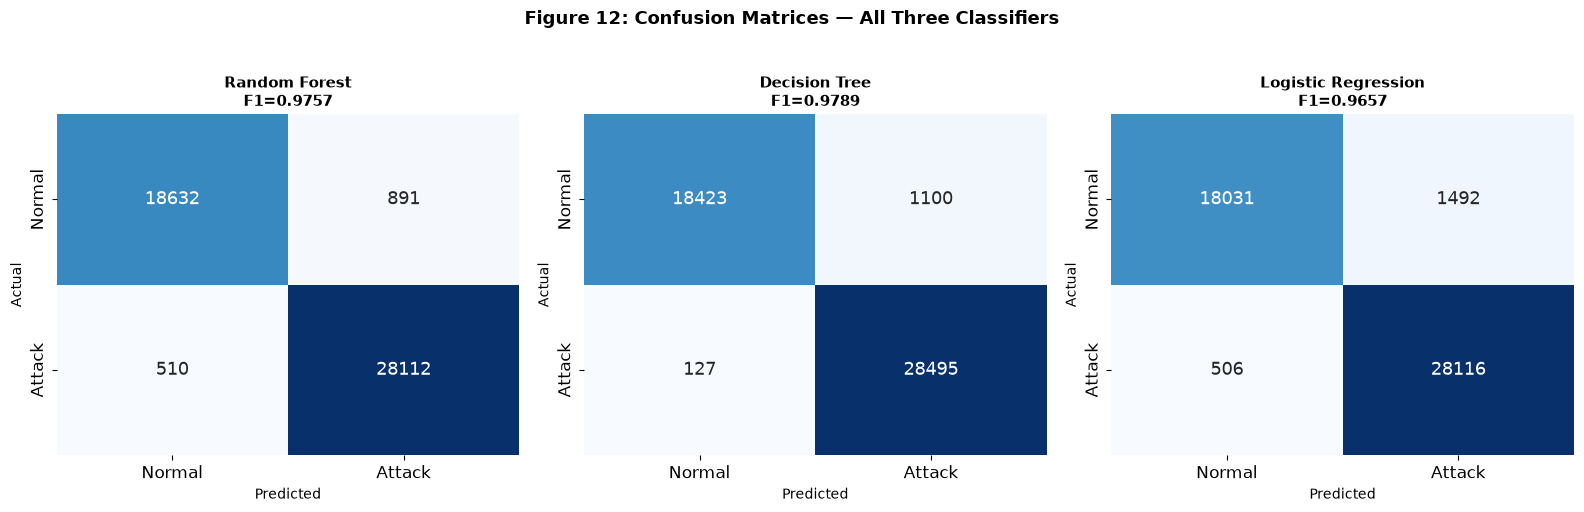

Saved: figure12_confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_list = [
    ('Random Forest',      rf,  X_test),
    ('Decision Tree',      dt,  X_test),
    ('Logistic Regression',lr,  X_test_scaled),
]

for ax, (name, model, X_eval) in zip(axes, model_list):
    cm = confusion_matrix(y_test, model.predict(X_eval))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Normal','Attack'],
        yticklabels=['Normal','Attack'],
        ax=ax,
        cbar=False,
        annot_kws={'size': 13}
    )
    
    f1 = results[name]['Attack']['f1-score']
    ax.set_title(f'{name}\nF1={f1:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Figure 12: Confusion Matrices — All Three Classifiers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure12_confusion_matrices.png")

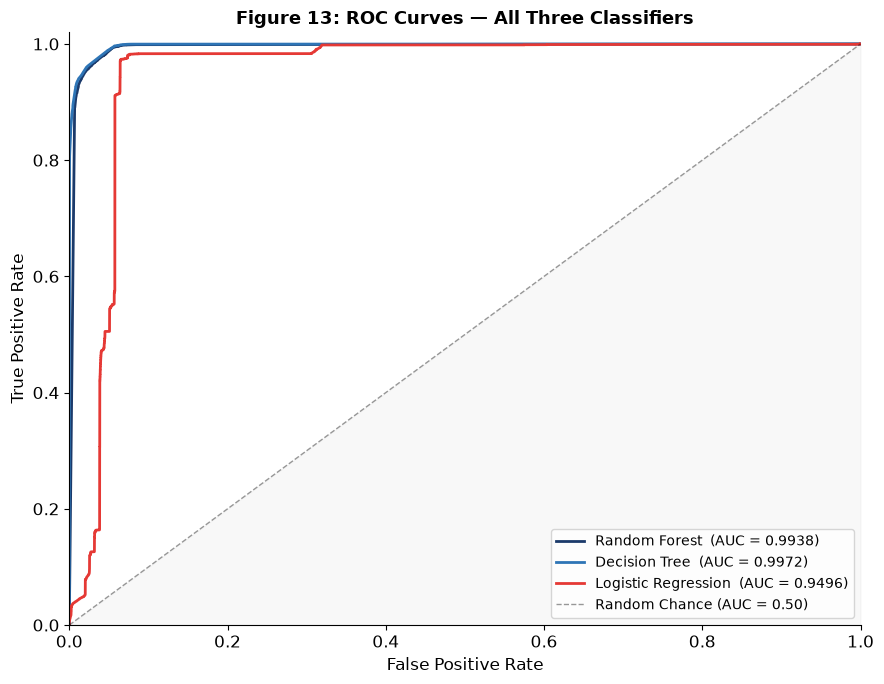

Saved: figure13_roc_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1B3A6B', '#2E75B6', '#E53935']
model_roc_list = [
    ('Random Forest',       rf,  X_test),
    ('Decision Tree',       dt,  X_test),
    ('Logistic Regression', lr,  X_test_scaled),
]

for (name, model, X_eval), color in zip(model_roc_list, colors):
    proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {roc_auc:.4f})')

# Diagonal chance line
ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1, label='Random Chance (AUC = 0.50)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 13: ROC Curves — All Three Classifiers',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')

plt.tight_layout()
plt.savefig('figure13_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure13_roc_curves.png")

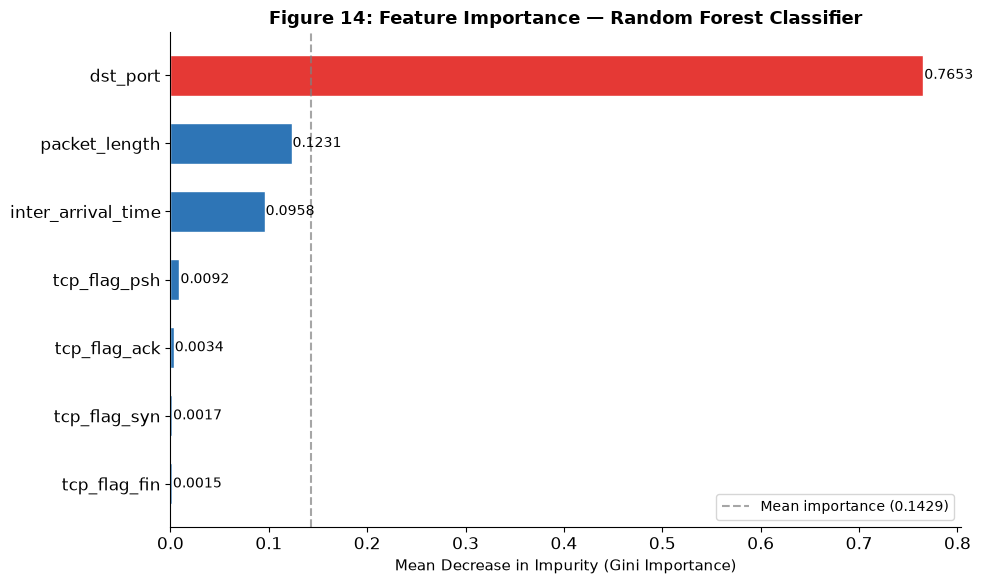

Feature importance ranking:
  dst_port                  0.7653
  packet_length             0.1231
  inter_arrival_time        0.0958
  tcp_flag_psh              0.0092
  tcp_flag_ack              0.0034
  tcp_flag_syn              0.0017
  tcp_flag_fin              0.0015


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values()

colors_bar = ['#E53935' if v > importances.mean() else '#2E75B6' 
              for v in importances_sorted.values]

bars = ax.barh(
    importances_sorted.index,
    importances_sorted.values,
    color=colors_bar,
    edgecolor='white',
    height=0.6
)

# Value labels
for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=11)
ax.set_title('Figure 14: Feature Importance — Random Forest Classifier',
             fontsize=13, fontweight='bold')
ax.axvline(importances.mean(), color='grey', linestyle='--',
           alpha=0.7, linewidth=1.5, label=f'Mean importance ({importances.mean():.4f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figure14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:<25} {imp:.4f}")

In [14]:
print("5-Fold Cross-Validation — Random Forest")
print("(This may take 1-2 minutes)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1', n_jobs=-1)

print(f"\nF1 scores per fold: {[round(s,4) for s in cv_scores]}")
print(f"Mean F1:  {cv_scores.mean():.4f}")
print(f"Std Dev:  {cv_scores.std():.4f}")
print(f"95% CI:   [{cv_scores.mean()-2*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+2*cv_scores.std():.4f}]")
print()
print("A low std dev confirms the model generalises well")
print("and is not overfitting to the training split.")

5-Fold Cross-Validation — Random Forest
(This may take 1-2 minutes)

F1 scores per fold: [np.float64(0.9753), np.float64(0.9748), np.float64(0.9757), np.float64(0.9758), np.float64(0.9759)]
Mean F1:  0.9755
Std Dev:  0.0004
95% CI:   [0.9747, 0.9763]

A low std dev confirms the model generalises well
and is not overfitting to the training split.


In [15]:
# Save Random Forest as primary model
joblib.dump(rf,     'attack_detector.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("Models saved:")
print("  attack_detector.pkl  — Random Forest classifier")
print("  feature_scaler.pkl   — StandardScaler (for LR inference)")

print()
print("=" * 55)
print("DAY 8 COMPLETE — RESULTS SUMMARY")
print("=" * 55)

for name, report in results.items():
    p  = report['Attack']['precision']
    r  = report['Attack']['recall']
    f1 = report['Attack']['f1-score']
    acc= report['accuracy']
    print(f"\n{name}")
    print(f"  Precision:  {p:.4f}")
    print(f"  Recall:     {r:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Accuracy:   {acc:.4f}")

print()
print("Figures saved for dissertation:")
for f in [
    'figure12_confusion_matrices.png',
    'figure13_roc_curves.png',
    'figure14_feature_importance.png',
]:
    import os
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"  {status}  {f}")

print()
print("Next step: Day 9 — Writing Sprint")
print("Fill in the [XX] placeholders in Dissertation_Full_Draft.docx")
print("using the exact numbers printed above.")

Models saved:
  attack_detector.pkl  — Random Forest classifier
  feature_scaler.pkl   — StandardScaler (for LR inference)

DAY 8 COMPLETE — RESULTS SUMMARY

Random Forest
  Precision:  0.9693
  Recall:     0.9822
  F1-Score:   0.9757
  Accuracy:   0.9709

Decision Tree
  Precision:  0.9628
  Recall:     0.9956
  F1-Score:   0.9789
  Accuracy:   0.9745

Logistic Regression
  Precision:  0.9496
  Recall:     0.9823
  F1-Score:   0.9657
  Accuracy:   0.9585

Figures saved for dissertation:
  ✓  figure12_confusion_matrices.png
  ✓  figure13_roc_curves.png
  ✓  figure14_feature_importance.png

Next step: Day 9 — Writing Sprint
Fill in the [XX] placeholders in Dissertation_Full_Draft.docx
using the exact numbers printed above.


In [16]:
# =========================================================
# PORT ABLATION TEST
# Does the model still detect attacks WITHOUT dst_port?
# =========================================================

FEATURE_COLS_NO_PORT = [
    'packet_length',
    'inter_arrival_time',
    'tcp_flag_syn',
    'tcp_flag_fin',
    'tcp_flag_psh',
    'tcp_flag_ack',
]

X_noport = df[FEATURE_COLS_NO_PORT].copy()
X_noport['inter_arrival_time'] = X_noport['inter_arrival_time'].clip(upper=iat_cap)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_noport, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_noport = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_noport.fit(X_train_np, y_train_np)

preds_noport = rf_noport.predict(X_test_np)
report_noport = classification_report(
    y_test_np, preds_noport,
    target_names=['Normal', 'Attack'],
    output_dict=True
)

print("=" * 65)
print("COMPARISON: WITH dst_port  vs  WITHOUT dst_port")
print("=" * 65)
print(f"{'':<20} {'PRECISION':>10} {'RECALL':>8} {'F1':>8} {'ACCURACY':>10}")

p_with  = results['Random Forest']['Attack']['precision']
r_with  = results['Random Forest']['Attack']['recall']
f1_with = results['Random Forest']['Attack']['f1-score']
acc_with= results['Random Forest']['accuracy']
print(f"{'WITH dst_port':<20} {p_with:>10.4f} {r_with:>8.4f} {f1_with:>8.4f} {acc_with:>10.4f}")

p_no  = report_noport['Attack']['precision']
r_no  = report_noport['Attack']['recall']
f1_no = report_noport['Attack']['f1-score']
acc_no= report_noport['accuracy']
print(f"{'WITHOUT dst_port':<20} {p_no:>10.4f} {r_no:>8.4f} {f1_no:>8.4f} {acc_no:>10.4f}")

print()
drop = f1_with - f1_no
print(f"F1 drop when dst_port removed: {drop:.4f} ({drop/f1_with*100:.1f}% relative)")

if drop < 0.05:
    print("\n-> Small drop: model still detects attacks well using only")
    print("   timing/size/flag behaviour. dst_port helps but is not")
    print("   doing all the work -> genuine behavioural detection confirmed.")
elif drop < 0.15:
    print("\n-> Moderate drop: behaviour-only features still carry real")
    print("   signal, but dst_port was contributing meaningfully.")
    print("   Report this honestly as a partial dependency.")
else:
    print("\n-> Large drop: most detection power came from dst_port.")
    print("   This means the model is closer to 'service-based lookup'")
    print("   than genuine behavioural anomaly detection. Important")
    print("   limitation to report.")

# New feature importance ranking without port
importances_noport = pd.Series(rf_noport.feature_importances_, index=FEATURE_COLS_NO_PORT)
print("\nFeature importance WITHOUT dst_port:")
for feat, imp in importances_noport.sort_values(ascending=False).items():
    print(f"  {feat:<25} {imp:.4f}")

COMPARISON: WITH dst_port  vs  WITHOUT dst_port
                      PRECISION   RECALL       F1   ACCURACY
WITH dst_port            0.9693   0.9822   0.9757     0.9709
WITHOUT dst_port         0.8664   0.8585   0.8624     0.8372

F1 drop when dst_port removed: 0.1133 (11.6% relative)

-> Moderate drop: behaviour-only features still carry real
   signal, but dst_port was contributing meaningfully.
   Report this honestly as a partial dependency.

Feature importance WITHOUT dst_port:
  packet_length             0.5736
  inter_arrival_time        0.3638
  tcp_flag_psh              0.0524
  tcp_flag_fin              0.0048
  tcp_flag_syn              0.0032
  tcp_flag_ack              0.0021


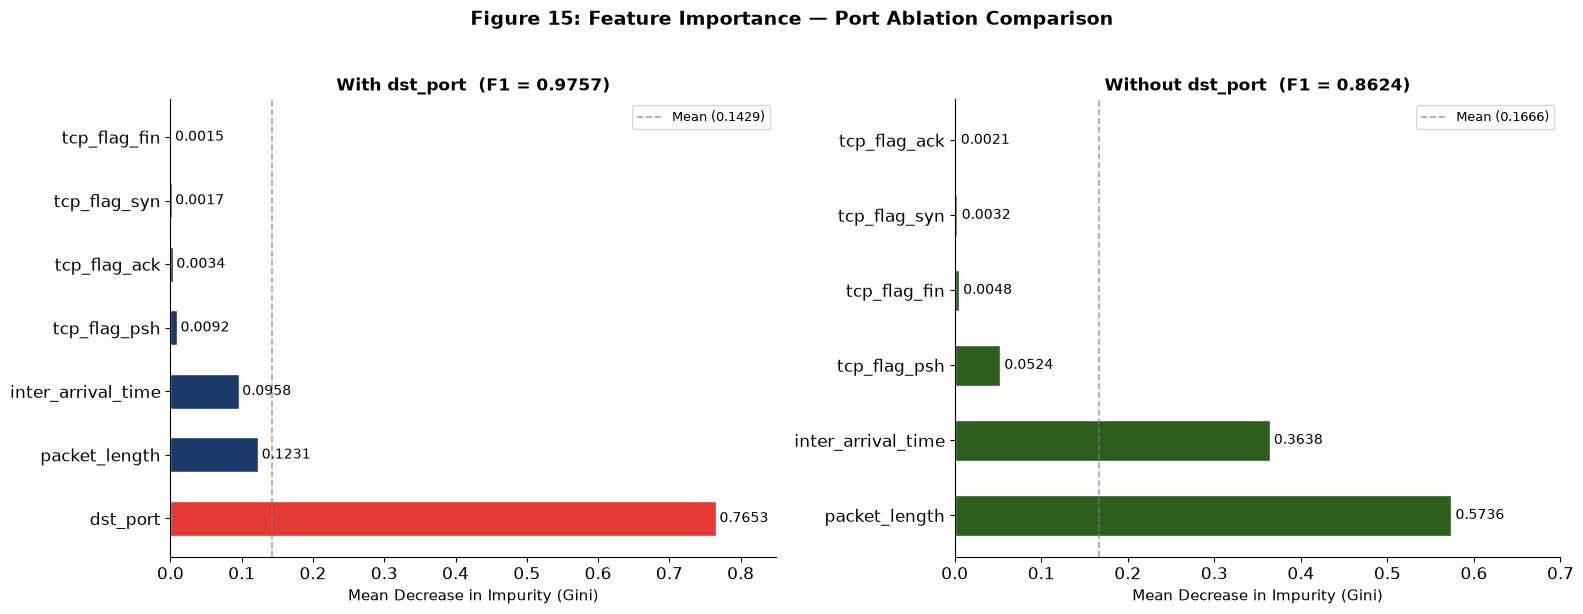

Saved: figure15_feature_importance_ablation.png


In [17]:
# Feature Importance Side-by-Side (With vs Without dst_port)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
features_with    = ['dst_port', 'packet_length', 'inter_arrival_time',
                    'tcp_flag_psh', 'tcp_flag_ack', 'tcp_flag_syn', 'tcp_flag_fin']
importance_with  = [0.7653, 0.1231, 0.0958, 0.0092, 0.0034, 0.0017, 0.0015]
 
features_without = ['packet_length', 'inter_arrival_time', 'tcp_flag_psh',
                    'tcp_flag_fin', 'tcp_flag_syn', 'tcp_flag_ack']
importance_without = [0.5736, 0.3638, 0.0524, 0.0048, 0.0032, 0.0021]
 
BLUE  = '#1B3A6B'
GREEN = '#2E5E1E'
 
ax = axes[0]
colors_l = [('#E53935' if f == 'dst_port' else BLUE) for f in features_with]
bars = ax.barh(features_with, importance_with, color=colors_l, height=0.55, edgecolor='white')
for bar, val in zip(bars, importance_with):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.axvline(np.mean(importance_with), color='grey', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Mean ({np.mean(importance_with):.4f})')
ax.set_xlim(0, 0.85)
ax.set_xlabel('Mean Decrease in Impurity (Gini)', fontsize=11)
ax.set_title('With dst_port  (F1 = 0.9757)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
ax = axes[1]
bars2 = ax.barh(features_without, importance_without,
                color=GREEN, height=0.55, edgecolor='white')
for bar, val in zip(bars2, importance_without):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.axvline(np.mean(importance_without), color='grey', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Mean ({np.mean(importance_without):.4f})')
ax.set_xlim(0, 0.70)
ax.set_xlabel('Mean Decrease in Impurity (Gini)', fontsize=11)
ax.set_title('Without dst_port  (F1 = 0.8624)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
fig.suptitle('Figure 15: Feature Importance — Port Ablation Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure15_feature_importance_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure15_feature_importance_ablation.png")

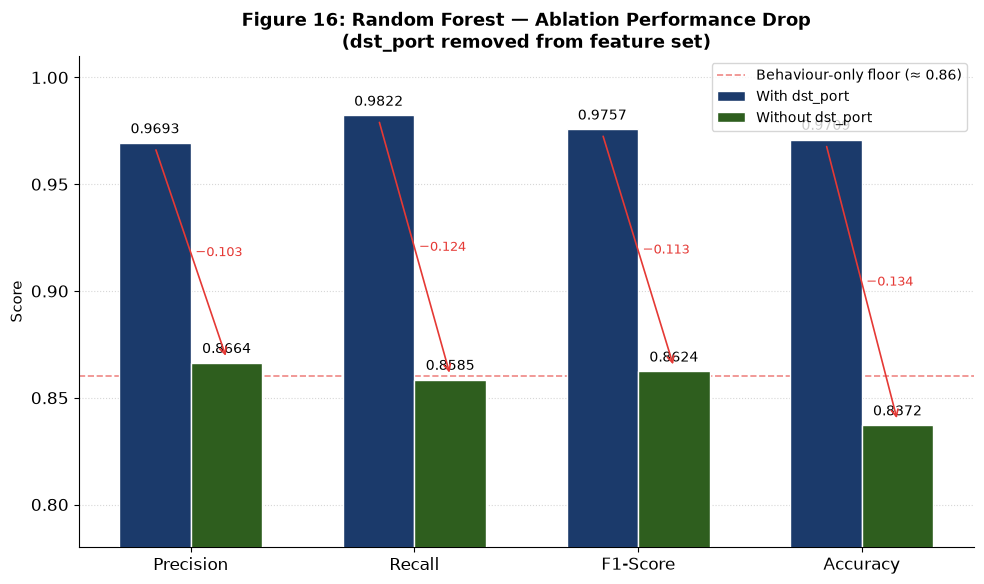

Saved: figure16_ablation_performance.png


In [18]:
# ── CELL: Figure 16 ─────────────────────────────────────────────
# Ablation Performance Drop (grouped bars + drop arrows)
 
metrics      = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
with_port    = [0.9693,      0.9822,   0.9757,     0.9709]
without_port = [0.8664,      0.8585,   0.8624,     0.8372]
 
x     = np.arange(len(metrics))
width = 0.32
 
fig, ax = plt.subplots(figsize=(10, 6))
 
bars1 = ax.bar(x - width / 2, with_port,    width, label='With dst_port',
               color=BLUE,  edgecolor='white', zorder=3)
bars2 = ax.bar(x + width / 2, without_port, width, label='Without dst_port',
               color=GREEN, edgecolor='white', zorder=3)
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
 
for i, (w, wo) in enumerate(zip(with_port, without_port)):
    drop = w - wo
    ax.annotate('', xy=(x[i] + width / 2, wo + 0.002),
                xytext=(x[i] - width / 2, w - 0.002),
                arrowprops=dict(arrowstyle='->', color='#E53935',
                                lw=1.2, connectionstyle='arc3,rad=0.0'))
    ax.text(x[i] + 0.02, (w + wo) / 2,
            f'−{drop:.3f}', fontsize=9, color='#E53935', va='center')
 
ax.axhline(0.86, color='#E53935', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Behaviour-only floor (≈ 0.86)', zorder=2)
 
ax.set_ylim(0.78, 1.01)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Figure 16: Random Forest — Ablation Performance Drop\n'
             '(dst_port removed from feature set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('figure16_ablation_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure16_ablation_performance.png")
 

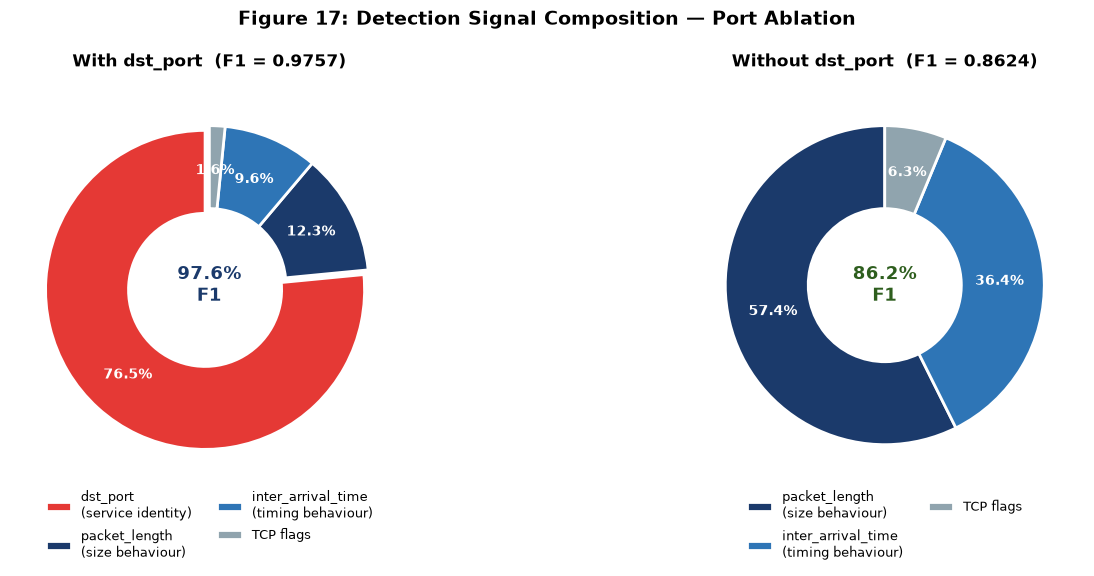

Saved: figure17_signal_composition.png


In [19]:
# ── CELL: Figure 17 ─────────────────────────────────────────────
# Detection Signal Composition — donut charts
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
ax = axes[0]
sizes_with   = [76.53, 12.31, 9.58, 1.58]
labels_with  = ['dst_port\n(service identity)', 'packet_length\n(size behaviour)',
                'inter_arrival_time\n(timing behaviour)', 'TCP flags']
colors_with  = ['#E53935', BLUE, '#2E75B6', '#90A4AE']
explode_with = (0.04, 0, 0, 0)
 
wedges, texts, autotexts = ax.pie(
    sizes_with, labels=None, colors=colors_with,
    autopct='%1.1f%%', startangle=90, explode=explode_with,
    pctdistance=0.72,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax.legend(wedges, labels_with, loc='lower center',
          bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9, frameon=False)
ax.set_title('With dst_port  (F1 = 0.9757)', fontsize=12, fontweight='bold', pad=14)
ax.text(0, 0, '97.6%\nF1', ha='center', va='center',
        fontsize=13, fontweight='bold', color=BLUE)
 
ax = axes[1]
sizes_without  = [57.36, 36.38, 6.26]
labels_without = ['packet_length\n(size behaviour)',
                  'inter_arrival_time\n(timing behaviour)',
                  'TCP flags']
colors_without = [BLUE, '#2E75B6', '#90A4AE']
 
wedges2, texts2, autotexts2 = ax.pie(
    sizes_without, labels=None, colors=colors_without,
    autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
)
for at in autotexts2:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax.legend(wedges2, labels_without, loc='lower center',
          bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9, frameon=False)
ax.set_title('Without dst_port  (F1 = 0.8624)', fontsize=12, fontweight='bold', pad=14)
ax.text(0, 0, '86.2%\nF1', ha='center', va='center',
        fontsize=13, fontweight='bold', color=GREEN)
 
fig.suptitle('Figure 17: Detection Signal Composition — Port Ablation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure17_signal_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure17_signal_composition.png")
 